In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load dataset
df = pd.read_excel("NSWRoadCrashData.xlsx")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace("–", "-", regex=False)
    .str.replace("—", "-", regex=False)
)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (93491, 50)

Columns:
['Crash ID', 'Degree of crash', 'Degree of crash - detailed', 'Reporting year', 'Year of crash', 'Month of crash', 'Day of week of crash', 'Two-hour intervals', 'Street of crash', 'Street type', 'Distance', 'Direction', 'Identifying feature', 'Identifying feature type', 'Town', 'Route no.', 'School zone location', 'School zone active', 'Type of location', 'Latitude', 'Longitude', 'LGA', 'Urbanisation', 'Conurbation 1', 'Alignment', 'Primary permanent feature', 'Primary temporary feature', 'Primary hazardous feature', 'Street lighting', 'Road surface', 'Surface condition', 'Weather', 'Natural lighting', 'Signals operation', 'Other traffic control', 'Speed limit', 'Road classification (admin)', 'RUM - code', 'RUM - description', 'DCA - code', 'DCA - description', 'DCA supplement', 'First impact type', 'Key TU type', 'Other TU type', 'No. of traffic units involved', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injur

,Crash ID,Degree of crash,Degree of crash - detailed,Reporting year,Year of crash,Month of crash,Day of week of crash,Two-hour intervals,Street of crash,Street type,...,DCA - description,DCA supplement,First impact type,Key TU type,Other TU type,No. of traffic units involved,No. killed,No. seriously injured,No. moderately injured,No. minor-other injured
0,1189190,Fatal,Fatal,2019,2019,January,Tuesday,02:00 - 03:59,SEXTONVILLE,RD,...,Off right bend into obj,Left,Vehicle - Object,Car (sedan/hatch),NaN,1,1,1,1,0
1,1189652,Fatal,Fatal,2019,2019,January,Wednesday,22:00 - Midnight,PACIFIC,HWY,...,Out of control on bend,NaN,Rollover,4 wheel drive,NaN,1,1,1,0,0
2,1189653,Fatal,Fatal,2019,2019,January,Thursday,12:00 - 13:59,OXLEY,HWY,...,Left off cway into object,NaN,Vehicle - Object,4 wheel drive,NaN,1,2,2,0,0
3,1189657,Fatal,Fatal,2019,2019,January,Saturday,06:00 - 07:59,HORSEFERRY,RD,...,Left off cway into object,NaN,Vehicle - Object,Car (sedan/hatch),NaN,1,1,0,0,0
4,1189658,Fatal,Fatal,2019,2019,January,Saturday,14:00 - 15:59,SUMMERLAND,WAY,...,Opp - Head on,NaN,Head-on,Car (sedan/hatch),4 wheel drive,2,1,1,2,2


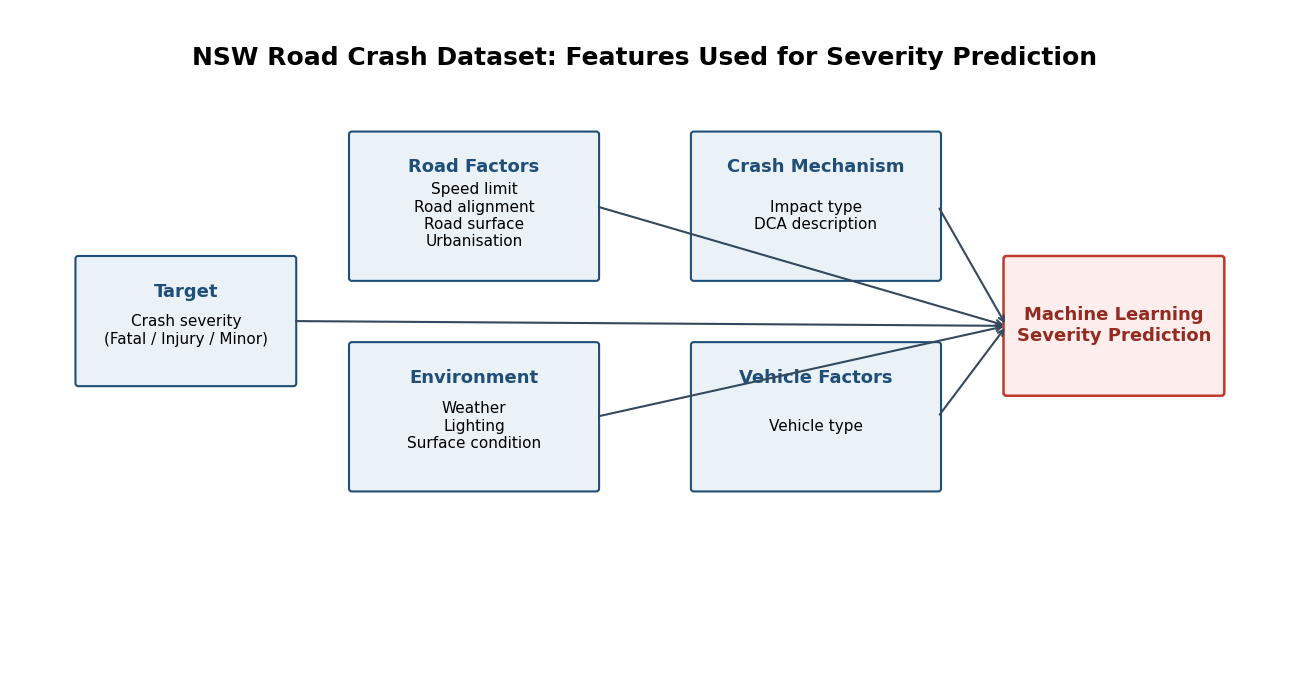

In [60]:
# ==========================================
# Methods Visual: Dataset Feature Overview
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

feature_groups = {
    "Target": ["Crash severity\n(Fatal / Injury / Minor)"],
    "Road Factors": ["Speed limit", "Road alignment", "Road surface", "Urbanisation"],
    "Environment": ["Weather", "Lighting", "Surface condition"],
    "Crash Mechanism": ["Impact type", "DCA description"],
    "Vehicle Factors": ["Vehicle type"]
}

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")

# Title
ax.text(
    6.5, 6.5,
    "NSW Road Crash Dataset: Features Used for Severity Prediction",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

positions = {
    "Target": (0.7, 3.1, 2.2, 1.3),
    "Road Factors": (3.5, 4.2, 2.5, 1.5),
    "Environment": (3.5, 2.0, 2.5, 1.5),
    "Crash Mechanism": (7.0, 4.2, 2.5, 1.5),
    "Vehicle Factors": (7.0, 2.0, 2.5, 1.5),
}

for group, items in feature_groups.items():
    x, y, w, h = positions[group]
    
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="#EAF2F8",
        edgecolor="#1F4E79"
    )
    ax.add_patch(box)
    
    ax.text(
        x + w/2, y + h - 0.25,
        group,
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold",
        color="#1F4E79"
    )
    
    item_text = "\n".join(items)
    ax.text(
        x + w/2, y + h/2 - 0.1,
        item_text,
        ha="center",
        va="center",
        fontsize=11
    )

# Central model box
model_box = FancyBboxPatch(
    (10.2, 3.0), 2.2, 1.4,
    boxstyle="round,pad=0.03",
    linewidth=1.8,
    facecolor="#FDEDEC",
    edgecolor="#C0392B"
)
ax.add_patch(model_box)

ax.text(
    11.3, 3.7,
    "Machine Learning\nSeverity Prediction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#922B21"
)

# Arrows
arrow_props = dict(arrowstyle="->", linewidth=1.5, color="#34495E")

for group in ["Road Factors", "Environment", "Crash Mechanism", "Vehicle Factors", "Target"]:
    x, y, w, h = positions[group]
    ax.annotate(
        "",
        xy=(10.2, 3.7),
        xytext=(x + w, y + h/2),
        arrowprops=arrow_props
    )

plt.tight_layout()
plt.savefig("dataset_feature_overview.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_clean = df.copy()

# Remove duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

# Check missing values
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percent": df_clean.isnull().mean() * 100
}).sort_values(by="Missing Percent", ascending=False)

print("\nMissing value summary:")
display(missing_summary[missing_summary["Missing Count"] > 0])

# Drop columns with more than 70% missing values
high_missing_cols = missing_summary[
    missing_summary["Missing Percent"] > 70
].index.tolist()

print("\nColumns with more than 70% missing values:")
print(high_missing_cols)

df_clean = df_clean.drop(columns=high_missing_cols)

print("\nShape after dropping high-missing columns:", df_clean.shape)

Number of duplicated rows: 0
Shape after removing duplicates: (93491, 50)

Missing value summary:


,Missing Count,Missing Percent
Primary temporary feature,92110,98.522852
Primary hazardous feature,91544,97.917447
DCA supplement,81242,86.898204
Primary permanent feature,69286,74.109807
Route no.,34737,37.155448
Other TU type,28433,30.412553



Columns with more than 70% missing values:
['Primary temporary feature', 'Primary hazardous feature', 'DCA supplement', 'Primary permanent feature']

Shape after dropping high-missing columns: (93491, 46)


In [ ]:


print("Original Degree of crash values:")
print(df_clean["Degree of crash"].value_counts(dropna=False))

Original Degree of crash values:
Degree of crash
Injury                    61965
Non-casualty (towaway)    30107
Fatal                      1419
Name: count, dtype: int64


In [25]:
# Create three-class target variable

df_model = df_clean.copy()

def map_severity(value):
    value = str(value).strip().lower()
    
    if "fatal" in value:
        return "Fatal"
    elif "injury" in value:
        return "Injury"
    else:
        return "Minor"

df_model["Severity_3class"] = df_model["Degree of crash"].apply(map_severity)

print("Three-class target distribution:")
print(df_model["Severity_3class"].value_counts())

print("\nThree-class target proportion:")
print(df_model["Severity_3class"].value_counts(normalize=True))

display(df_model[["Degree of crash", "Severity_3class"]].head(20))

Three-class target distribution:
Severity_3class
Injury    61965
Minor     30107
Fatal      1419
Name: count, dtype: int64

Three-class target proportion:
Severity_3class
Injury    0.662791
Minor     0.322031
Fatal     0.015178
Name: proportion, dtype: float64


,Degree of crash,Severity_3class
0,Fatal,Fatal
1,Fatal,Fatal
2,Fatal,Fatal
3,Fatal,Fatal
4,Fatal,Fatal
5,Fatal,Fatal
6,Fatal,Fatal
7,Fatal,Fatal
8,Fatal,Fatal
9,Fatal,Fatal


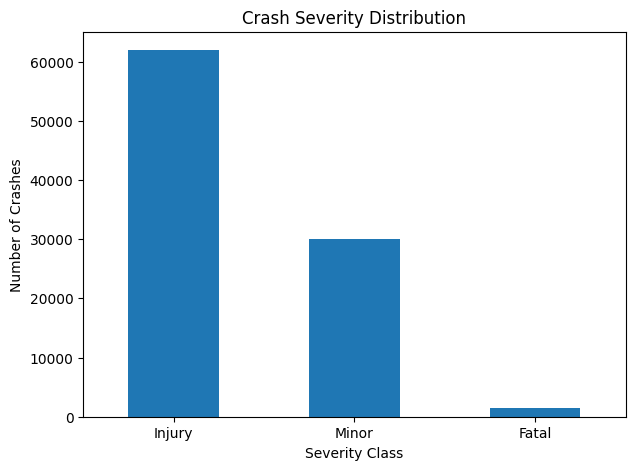

Three-class target counts:
Severity_3class
Injury    61965
Minor     30107
Fatal      1419
Name: count, dtype: int64

Three-class target proportions:
Severity_3class
Injury    0.662791
Minor     0.322031
Fatal     0.015178
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

df_model["Severity_3class"].value_counts().plot(kind="bar")

plt.title("Crash Severity Distribution")
plt.xlabel("Severity Class")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=0)
plt.show()

print("Three-class target counts:")
print(df_model["Severity_3class"].value_counts())

print("\nThree-class target proportions:")
print(df_model["Severity_3class"].value_counts(normalize=True))

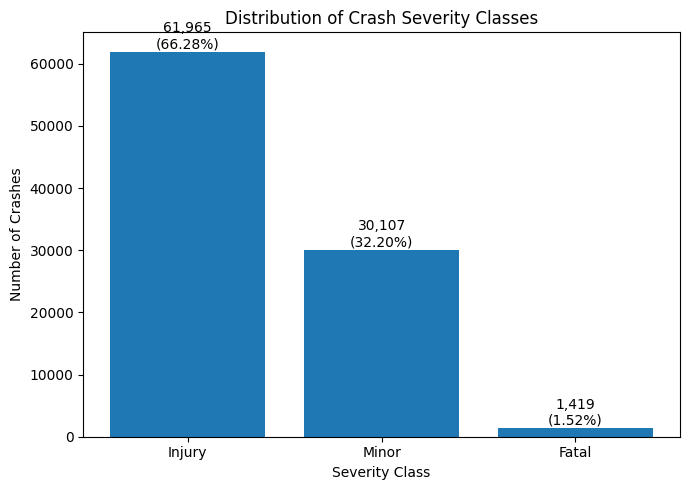

In [67]:
import matplotlib.pyplot as plt

severity_counts = df_model["Severity_3class"].value_counts()
severity_props = df_model["Severity_3class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(severity_counts.index, severity_counts.values)

plt.title("Distribution of Crash Severity Classes")
plt.xlabel("Severity Class")
plt.ylabel("Number of Crashes")

for bar, count, prop in zip(bars, severity_counts.values, severity_props.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({prop:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:


def plot_severity_by_feature(data, feature, target="Severity_3class", top_n=10):
    temp = data[[feature, target]].copy()
    temp = temp.dropna()
    
    top_categories = temp[feature].value_counts().head(top_n).index
    temp = temp[temp[feature].isin(top_categories)]
    
    table = pd.crosstab(
        temp[feature],
        temp[target],
        normalize="index"
    )
    
    display(table)
    
    table.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title("Severity Proportion by " + feature)
    plt.xlabel(feature)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Severity")
    plt.tight_layout()
    plt.show()

Severity_3class,Fatal,Injury,Minor
Weather,,,
Fine,0.014873,0.676094,0.309033
Fog or mist,0.029141,0.607362,0.363497
Other,0.032258,0.526882,0.440860
Overcast,0.021044,0.601823,0.377133
Raining,0.012951,0.609626,0.377423
Snowing,0.019608,0.598039,0.382353
Unknown,0.014134,0.683746,0.302120


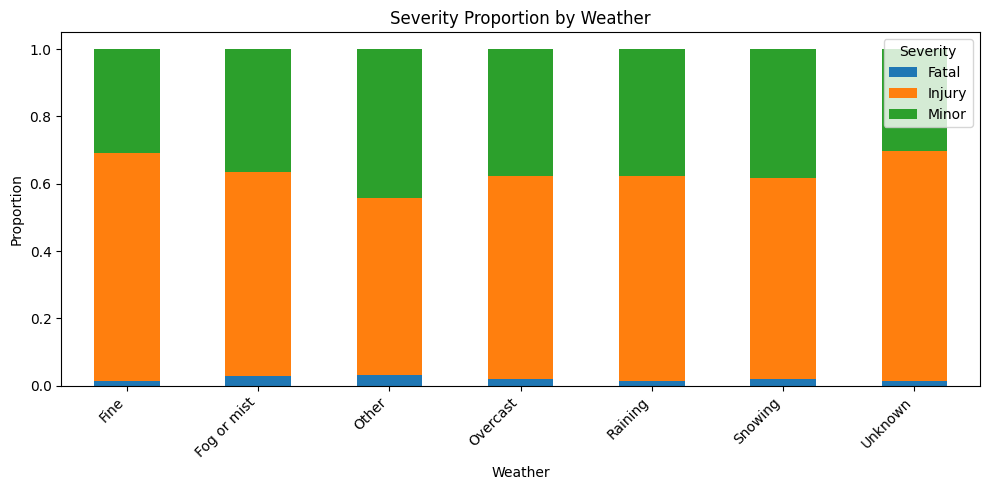

In [28]:
plot_severity_by_feature(df_model, "Weather")

Severity_3class,Fatal,Injury,Minor
Surface condition,,,
Dry,0.015421,0.674240,0.310339
Snow or ice,0.006211,0.571429,0.422360
Unknown,0.024180,0.694301,0.281520
Wet,0.013780,0.607806,0.378414


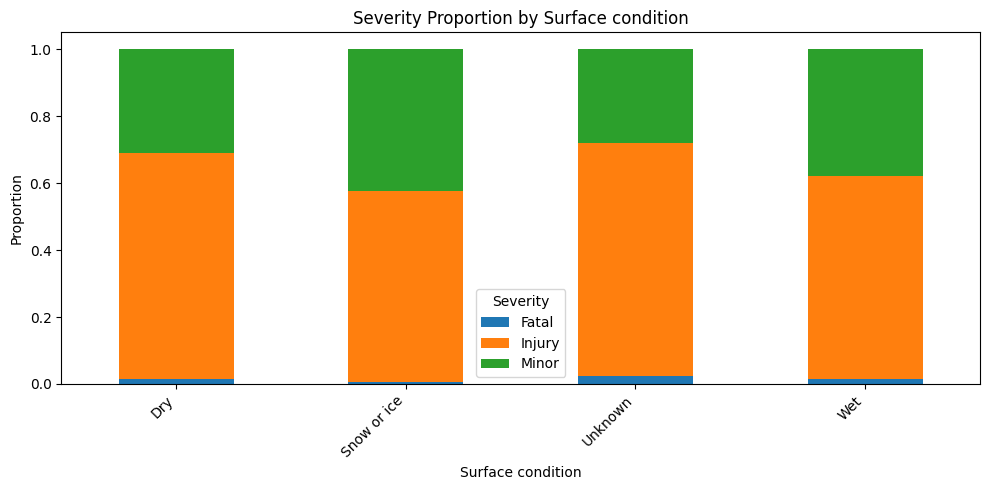

In [29]:
plot_severity_by_feature(df_model, "Surface condition")

Severity_3class,Fatal,Injury,Minor
Road surface,,,
Sealed,0.014986,0.660841,0.324174
Unknown,0.000000,0.779221,0.220779
Unsealed,0.023206,0.735281,0.241513


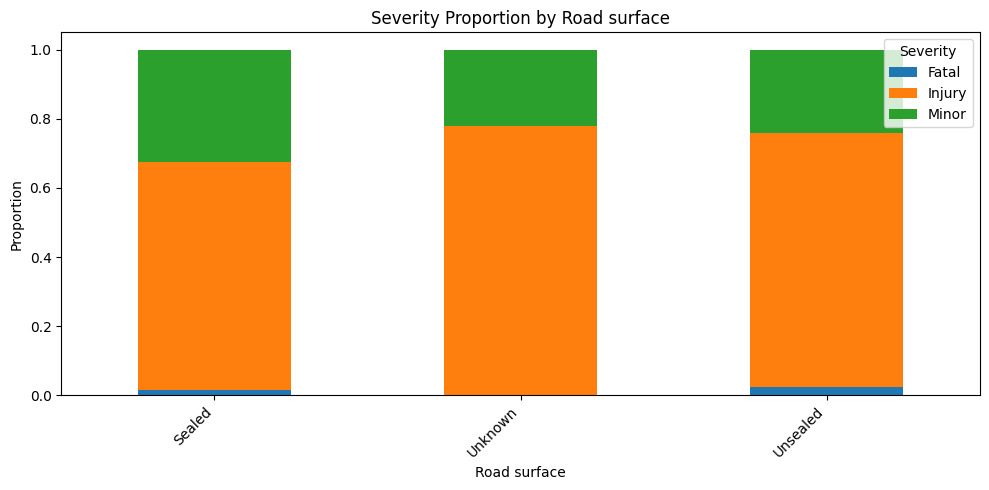

In [30]:
plot_severity_by_feature(df_model, "Road surface")

Severity_3class,Fatal,Injury,Minor
Natural lighting,,,
Darkness,0.018984,0.582652,0.398364
Dawn,0.017424,0.613877,0.368699
Daylight,0.013811,0.698043,0.288146
Dusk,0.013309,0.670683,0.316007
Unknown,0.000000,0.402204,0.597796


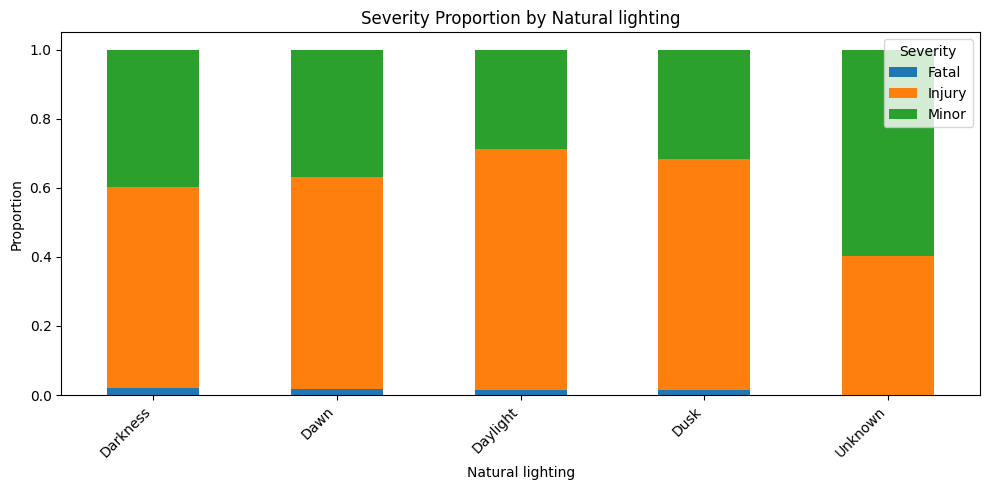

In [31]:
plot_severity_by_feature(df_model, "Natural lighting")

Severity_3class,Fatal,Injury,Minor
Speed limit,,,
10 km/h,0.015385,0.800000,0.184615
100 km/h,0.044700,0.652346,0.302954
110 km/h,0.031822,0.580483,0.387696
30 km/h,0.000000,0.866242,0.133758
40 km/h,0.007168,0.726838,0.265994
50 km/h,0.007925,0.629725,0.362350
60 km/h,0.008846,0.684038,0.307115
70 km/h,0.011644,0.685349,0.303007
80 km/h,0.023734,0.710911,0.265355


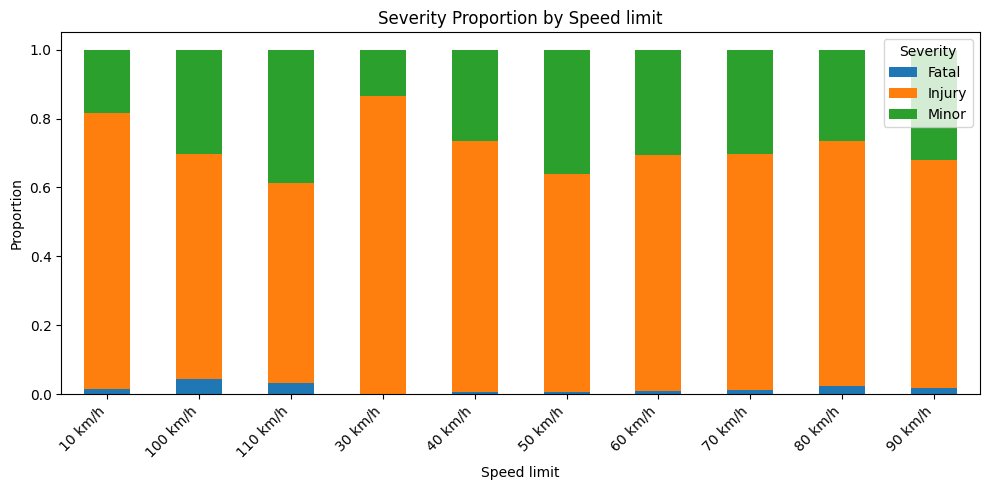

In [32]:
plot_severity_by_feature(df_model, "Speed limit")

Severity_3class,Fatal,Injury,Minor
First impact type,,,
Head-on,0.066613,0.729017,0.204370
Other angle,0.006046,0.579656,0.414298
Person - Object,0.042614,0.954545,0.002841
Rear end,0.002839,0.715196,0.281965
Right angle,0.005933,0.701107,0.292960
Rollover,0.017709,0.721836,0.260455
Unknown,0.006897,0.475862,0.517241
Vehicle - Animal,0.012953,0.506908,0.480138
Vehicle - Object,0.026598,0.594131,0.379271


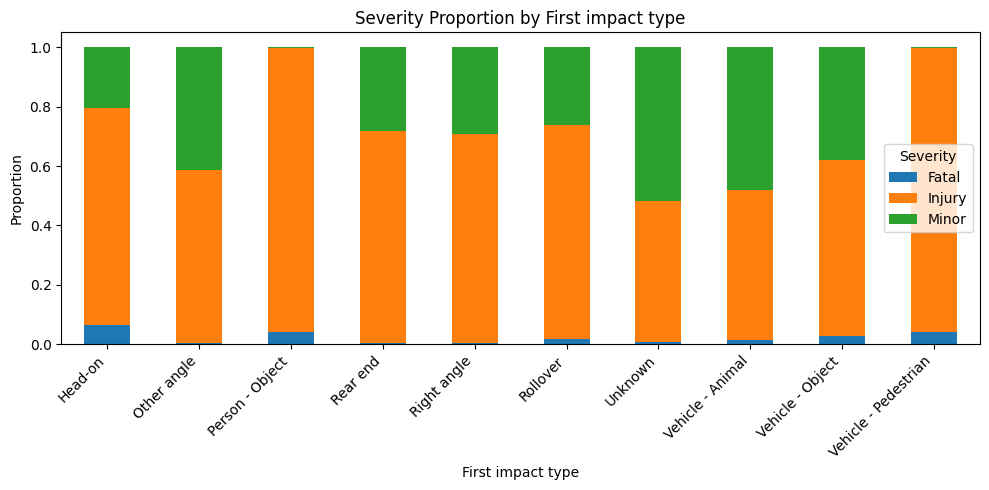

In [33]:
plot_severity_by_feature(df_model, "First impact type")

Severity_3class,Fatal,Injury,Minor
Key TU type,,,
4 wheel drive,0.011975,0.660083,0.327943
Car (sedan/hatch),0.011082,0.632989,0.355929
Large rigid,0.027804,0.591894,0.380302
Light truck,0.011915,0.655914,0.332171
Light truck utility(from 2018),0.019617,0.648692,0.331691
Motorcycle,0.033844,0.923932,0.042224
Pedal cycle,0.020179,0.972534,0.007287
Station wagon,0.011572,0.637622,0.350806
Unknown motor vehicle,0.003763,0.532258,0.463978


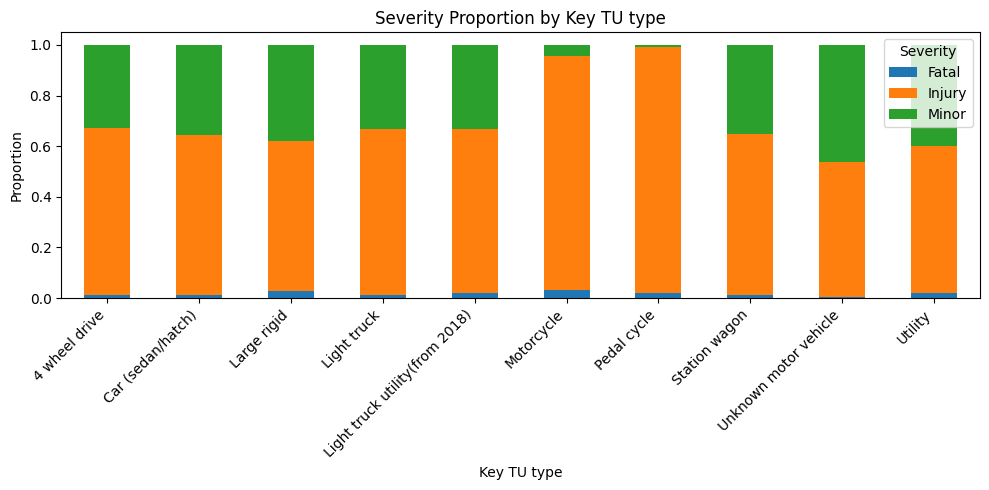

In [34]:
plot_severity_by_feature(df_model, "Key TU type")

In [ ]:
selected_features = [
    "Month of crash",
    "Day of week of crash",
    "Two-hour intervals",
    "Street type",
    "Urbanisation",
    "Alignment",
    "Road surface",
    "Surface condition",
    "Weather",
    "Natural lighting",
    "Speed limit",
    "Road classification (admin)",
    "DCA - description",
    "First impact type",
    "Key TU type"
]

target = "Severity_3class"

missing_features = []

for col in selected_features:
    if col not in df_model.columns:
        missing_features.append(col)

print("Missing selected features:")
print(missing_features)

selected_features = [col for col in selected_features if col in df_model.columns]

print("\nFinal selected features:")
print(selected_features)

data_model = df_model[selected_features + [target]].copy()

print("\nShape before missing value handling:", data_model.shape)

display(data_model.head())

Missing selected features:
[]

Final selected features:
['Month of crash', 'Day of week of crash', 'Two-hour intervals', 'Street type', 'Urbanisation', 'Alignment', 'Road surface', 'Surface condition', 'Weather', 'Natural lighting', 'Speed limit', 'Road classification (admin)', 'DCA - description', 'First impact type', 'Key TU type']

Shape before missing value handling: (93491, 16)


,Month of crash,Day of week of crash,Two-hour intervals,Street type,Urbanisation,Alignment,Road surface,Surface condition,Weather,Natural lighting,Speed limit,Road classification (admin),DCA - description,First impact type,Key TU type,Severity_3class
0,January,Tuesday,02:00 - 03:59,RD,Country urban,Curved,Sealed,Dry,Fine,Darkness,60 km/h,Local,Off right bend into obj,Vehicle - Object,Car (sedan/hatch),Fatal
1,January,Wednesday,22:00 - Midnight,HWY,Country non-urban,Curved,Sealed,Dry,Fine,Darkness,110 km/h,State,Out of control on bend,Rollover,4 wheel drive,Fatal
2,January,Thursday,12:00 - 13:59,HWY,Country non-urban,Straight,Sealed,Dry,Fine,Daylight,110 km/h,State,Left off cway into object,Vehicle - Object,4 wheel drive,Fatal
3,January,Saturday,06:00 - 07:59,RD,Country non-urban,Straight,Unsealed,Dry,Fine,Daylight,100 km/h,Local,Left off cway into object,Vehicle - Object,Car (sedan/hatch),Fatal
4,January,Saturday,14:00 - 15:59,WAY,Country non-urban,Straight,Sealed,Dry,Fine,Daylight,100 km/h,State,Opp - Head on,Head-on,Car (sedan/hatch),Fatal


In [ ]:


data_model = data_model.copy()

for col in selected_features:
    data_model[col] = data_model[col].fillna("Unknown")

data_model = data_model.dropna(subset=[target])

print("Shape after missing value handling:", data_model.shape)

print("\nMissing values after cleaning:")
print(data_model.isnull().sum())

display(data_model.head())

Shape after missing value handling: (93491, 16)

Missing values after cleaning:
Month of crash                 0
Day of week of crash           0
Two-hour intervals             0
Street type                    0
Urbanisation                   0
Alignment                      0
Road surface                   0
Surface condition              0
Weather                        0
Natural lighting               0
Speed limit                    0
Road classification (admin)    0
DCA - description              0
First impact type              0
Key TU type                    0
Severity_3class                0
dtype: int64


,Month of crash,Day of week of crash,Two-hour intervals,Street type,Urbanisation,Alignment,Road surface,Surface condition,Weather,Natural lighting,Speed limit,Road classification (admin),DCA - description,First impact type,Key TU type,Severity_3class
0,January,Tuesday,02:00 - 03:59,RD,Country urban,Curved,Sealed,Dry,Fine,Darkness,60 km/h,Local,Off right bend into obj,Vehicle - Object,Car (sedan/hatch),Fatal
1,January,Wednesday,22:00 - Midnight,HWY,Country non-urban,Curved,Sealed,Dry,Fine,Darkness,110 km/h,State,Out of control on bend,Rollover,4 wheel drive,Fatal
2,January,Thursday,12:00 - 13:59,HWY,Country non-urban,Straight,Sealed,Dry,Fine,Daylight,110 km/h,State,Left off cway into object,Vehicle - Object,4 wheel drive,Fatal
3,January,Saturday,06:00 - 07:59,RD,Country non-urban,Straight,Unsealed,Dry,Fine,Daylight,100 km/h,Local,Left off cway into object,Vehicle - Object,Car (sedan/hatch),Fatal
4,January,Saturday,14:00 - 15:59,WAY,Country non-urban,Straight,Sealed,Dry,Fine,Daylight,100 km/h,State,Opp - Head on,Head-on,Car (sedan/hatch),Fatal


In [ ]:
X = data_model[selected_features].copy()
y = data_model[target].copy()

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

display(X_encoded.head())

Original feature shape: (93491, 15)
Encoded feature shape: (93491, 227)


,Month of crash_August,Month of crash_December,Month of crash_February,Month of crash_January,Month of crash_July,Month of crash_June,Month of crash_March,Month of crash_May,Month of crash_November,Month of crash_October,...,Key TU type_Road train,Key TU type_STA bus,Key TU type_Self prop plant,Key TU type_Semi-trailer,Key TU type_Station wagon,Key TU type_Tractor,Key TU type_Tram,Key TU type_Unknown motor vehicle,Key TU type_Unknown type,Key TU type_Utility
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:


label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

print("\nEncoded target sample:")
print(y_encoded[:20])

Class mapping:
0 = Fatal
1 = Injury
2 = Minor

Encoded target sample:
[0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 2 2 2 2 2]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Training set shape: (74792, 227)
Testing set shape: (18699, 227)

Training class distribution:
1    0.662798
2    0.322026
0    0.015175
Name: proportion, dtype: float64

Testing class distribution:
1    0.662763
2    0.322049
0    0.015188
Name: proportion, dtype: float64


In [ ]:


log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.49034707738381733

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.05      0.66      0.08       284
      Injury       0.76      0.44      0.56     12393
       Minor       0.48      0.58      0.52      6022

    accuracy                           0.49     18699
   macro avg       0.43      0.56      0.39     18699
weighted avg       0.66      0.49      0.54     18699


Confusion Matrix:
[[ 187   43   54]
 [3134 5474 3785]
 [ 833 1681 3508]]


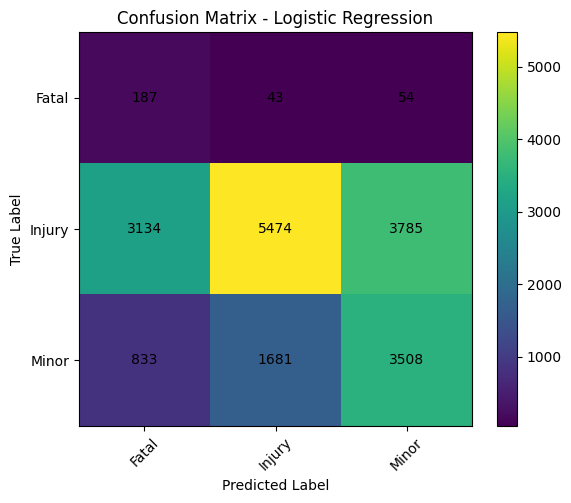

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
plt.imshow(cm_lr)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:


dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy:
0.44751056206214235

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.04      0.51      0.08       284
      Injury       0.79      0.32      0.45     12393
       Minor       0.41      0.72      0.52      6022

    accuracy                           0.45     18699
   macro avg       0.41      0.52      0.35     18699
weighted avg       0.65      0.45      0.47     18699


Confusion Matrix:
[[ 146   58   80]
 [2449 3910 6034]
 [ 705 1005 4312]]


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy:
0.5381571207016418

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.05      0.53      0.09       284
      Injury       0.78      0.51      0.62     12393
       Minor       0.47      0.60      0.53      6022

    accuracy                           0.54     18699
   macro avg       0.43      0.55      0.41     18699
weighted avg       0.67      0.54      0.58     18699


Confusion Matrix:
[[ 151   76   57]
 [2052 6305 4036]
 [ 704 1711 3607]]


In [ ]:


model_results = []

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for model_name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })

model_comparison = pd.DataFrame(model_results)

display(model_comparison)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.490347,0.427660,0.560894,0.389299
1,Decision Tree,0.447511,0.414690,0.515209,0.352032
2,Random Forest,0.538157,0.433183,0.546472,0.411980


Top 20 important features:


,Feature,Importance
190,First impact type_Vehicle - Pedestrian,0.063053
86,Speed limit_100 km/h,0.058131
140,DCA - description_Opp - Head on,0.049838
182,First impact type_Other angle,0.045175
207,Key TU type_Motorcycle,0.044744
67,Urbanisation_Sydney metro. area,0.042821
184,First impact type_Rear end,0.035533
91,Speed limit_50 km/h,0.032002
189,First impact type_Vehicle - Object,0.023366
175,DCA - description_Same - Rear end,0.021379


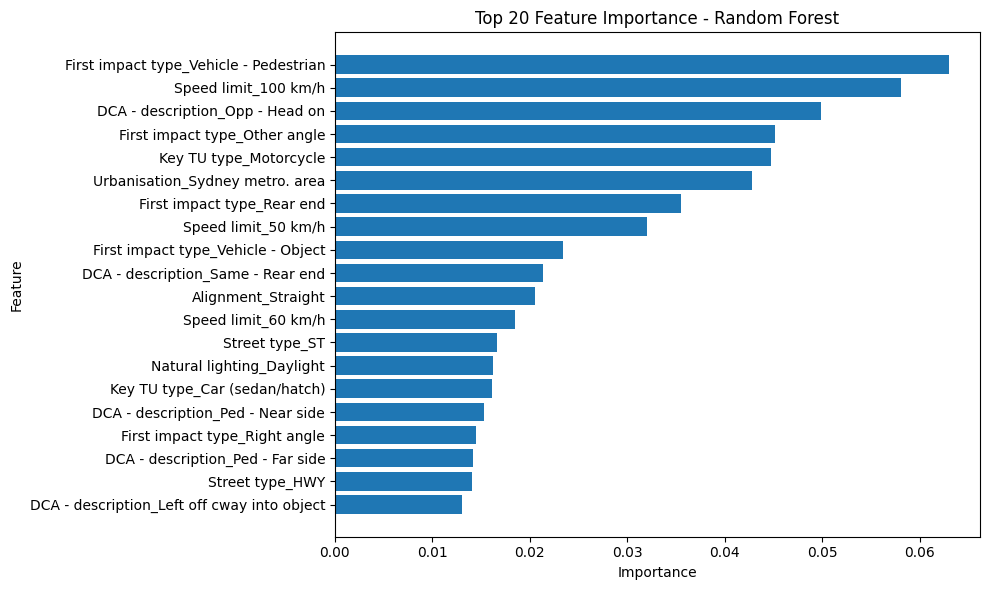

In [ ]:
importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 important features:")
display(feature_importance_df.head(20))

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"].head(20),
    feature_importance_df["Importance"].head(20)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:


rf_optimised = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_optimised.fit(X_train, y_train)

y_pred_rf_opt = rf_optimised.predict(X_test)

print("Optimised Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf_opt))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf_opt,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_opt))

Optimised Random Forest Accuracy:
0.6329215466067705

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.08      0.20      0.11       284
      Injury       0.76      0.67      0.71     12393
       Minor       0.49      0.58      0.53      6022

    accuracy                           0.63     18699
   macro avg       0.44      0.48      0.45     18699
weighted avg       0.67      0.63      0.65     18699


Confusion Matrix:
[[  58  169   57]
 [ 523 8293 3577]
 [ 145 2393 3484]]


In [ ]:
models_updated = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Optimised Random Forest": y_pred_rf_opt
}

updated_results = []

for model_name, y_pred in models_updated.items():
    updated_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

updated_comparison = pd.DataFrame(updated_results)

display(updated_comparison)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.490347,0.427660,0.560894,0.389299
1,Decision Tree,0.447511,0.414690,0.515209,0.352032
2,Random Forest,0.538157,0.433183,0.546472,0.411980
3,Optimised Random Forest,0.632922,0.444444,0.483980,0.452859


,Feature,Importance
190,First impact type_Vehicle - Pedestrian,0.040342
86,Speed limit_100 km/h,0.032880
207,Key TU type_Motorcycle,0.032687
140,DCA - description_Opp - Head on,0.031220
67,Urbanisation_Sydney metro. area,0.029598
182,First impact type_Other angle,0.028044
91,Speed limit_50 km/h,0.022520
196,Key TU type_Car (sedan/hatch),0.019078
184,First impact type_Rear end,0.018573
69,Alignment_Straight,0.017806


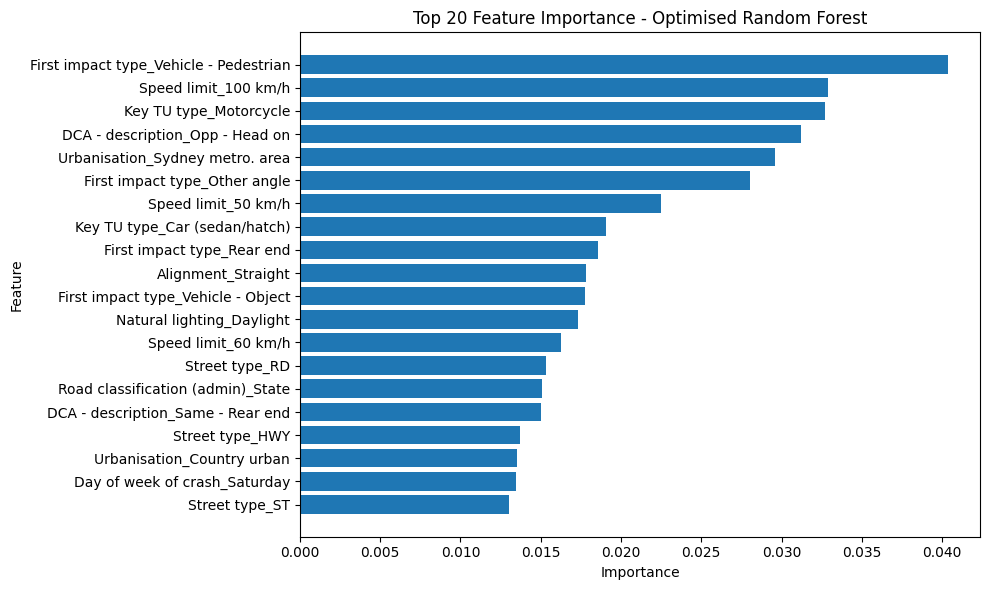

In [ ]:


importance_opt = rf_optimised.feature_importances_

feature_importance_opt_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": importance_opt
})

feature_importance_opt_df = feature_importance_opt_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_opt_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_opt_df["Feature"].head(20),
    feature_importance_opt_df["Importance"].head(20)
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance - Optimised Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [53]:
pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from imblearn.over_sampling import SMOTE

# Convert boolean dummy variables to integers
X_train_num = X_train.astype(int)
X_test_num = X_test.astype(int)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_num,
    y_train
)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
1    49572
2    24085
0     1135
Name: count, dtype: int64

After SMOTE:
2    49572
1    49572
0    49572
Name: count, dtype: int64


In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test_num)

print("Random Forest with SMOTE Accuracy:")
print(accuracy_score(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Random Forest with SMOTE Accuracy:
0.6248997272581421

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.08      0.26      0.12       284
      Injury       0.75      0.69      0.72     12393
       Minor       0.49      0.52      0.50      6022

    accuracy                           0.62     18699
   macro avg       0.44      0.49      0.45     18699
weighted avg       0.65      0.62      0.64     18699


Confusion Matrix:
[[  75  162   47]
 [ 704 8495 3194]
 [ 211 2696 3115]]


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_optimised,
    X_encoded,
    y_encoded,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Macro F1:")
print(cv_scores.mean())

Cross Validation Scores:
[0.45922467 0.4614719  0.45975248 0.44888251 0.44826457]

Average Macro F1:
0.4555192251201207


In [ ]:
train_acc = rf_optimised.score(X_train, y_train)
test_acc = rf_optimised.score(X_test, y_test)

print("Training Accuracy:")
print(train_acc)

print("\nTesting Accuracy:")
print(test_acc)

Training Accuracy:
0.784629372125361

Testing Accuracy:
0.6329215466067705


In [ ]:
top_features = feature_importance_opt_df["Feature"].head(15)

X_top = X_encoded[top_features]

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

rf_top = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_top.fit(X_train_top, y_train_top)

y_pred_top = rf_top.predict(X_test_top)

print(classification_report(
    y_test_top,
    y_pred_top,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

       Fatal       0.50      0.01      0.01       284
      Injury       0.69      0.92      0.79     12393
       Minor       0.53      0.19      0.28      6022

    accuracy                           0.67     18699
   macro avg       0.57      0.37      0.36     18699
weighted avg       0.64      0.67      0.61     18699



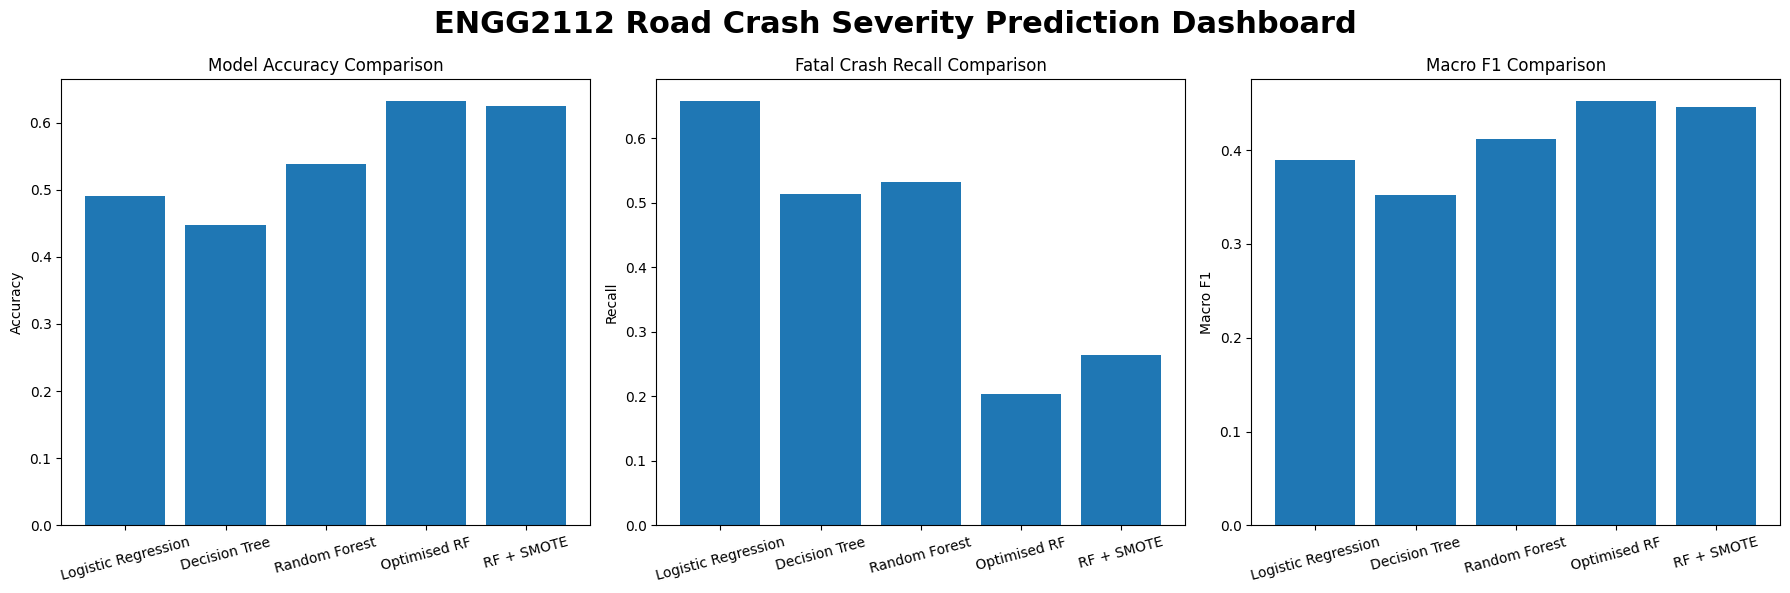

In [65]:
# ==========================================
# ONLY THE TOP 3 PERFORMANCE CHARTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score
)

# ==========================================
# Automatically Calculate Metrics
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Optimised RF",
        "RF + SMOTE"
    ],

    # Accuracy
    "Accuracy": [

        accuracy_score(y_test, y_pred_lr),

        accuracy_score(y_test, y_pred_dt),

        accuracy_score(y_test, y_pred_rf),

        accuracy_score(y_test, y_pred_rf_opt),

        accuracy_score(y_test, y_pred_smote)
    ],

    # Fatal Recall
    "Fatal Recall": [

        recall_score(
            y_test,
            y_pred_lr,
            labels=[0],
            average="macro",
            zero_division=0
        ),

        recall_score(
            y_test,
            y_pred_dt,
            labels=[0],
            average="macro",
            zero_division=0
        ),

        recall_score(
            y_test,
            y_pred_rf,
            labels=[0],
            average="macro",
            zero_division=0
        ),

        recall_score(
            y_test,
            y_pred_rf_opt,
            labels=[0],
            average="macro",
            zero_division=0
        ),

        recall_score(
            y_test,
            y_pred_smote,
            labels=[0],
            average="macro",
            zero_division=0
        )
    ],

    # Macro F1
    "Macro F1": [

        f1_score(
            y_test,
            y_pred_lr,
            average="macro",
            zero_division=0
        ),

        f1_score(
            y_test,
            y_pred_dt,
            average="macro",
            zero_division=0
        ),

        f1_score(
            y_test,
            y_pred_rf,
            average="macro",
            zero_division=0
        ),

        f1_score(
            y_test,
            y_pred_rf_opt,
            average="macro",
            zero_division=0
        ),

        f1_score(
            y_test,
            y_pred_smote,
            average="macro",
            zero_division=0
        )
    ]
})

# ==========================================
# Create Figure
# ==========================================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# ==========================================
# 1. Accuracy Comparison
# ==========================================

axs[0].bar(
    results["Model"],
    results["Accuracy"]
)

axs[0].set_title("Model Accuracy Comparison")
axs[0].set_ylabel("Accuracy")
axs[0].tick_params(axis='x', rotation=15)

# ==========================================
# 2. Fatal Recall Comparison
# ==========================================

axs[1].bar(
    results["Model"],
    results["Fatal Recall"]
)

axs[1].set_title("Fatal Crash Recall Comparison")
axs[1].set_ylabel("Recall")
axs[1].tick_params(axis='x', rotation=15)

# ==========================================
# 3. Macro F1 Comparison
# ==========================================

axs[2].bar(
    results["Model"],
    results["Macro F1"]
)

axs[2].set_title("Macro F1 Comparison")
axs[2].set_ylabel("Macro F1")
axs[2].tick_params(axis='x', rotation=15)

# ==========================================
# Main Title
# ==========================================

fig.suptitle(
    "ENGG2112 Road Crash Severity Prediction Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

# ==========================================
# Save Figure
# ==========================================

plt.savefig(
    "ENGG2112_metrics_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Find the encoded label number for Fatal
fatal_label = list(label_encoder.classes_).index("Fatal")

models_final = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Optimised Random Forest": y_pred_rf_opt,
    "Random Forest + SMOTE": y_pred_smote
}

final_results = []

for model_name, y_pred in models_final.items():
    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Fatal Precision": precision_score(y_test, y_pred, labels=[fatal_label], average="macro", zero_division=0),
        "Fatal Recall": recall_score(y_test, y_pred, labels=[fatal_label], average="macro", zero_division=0),
        "Fatal F1": f1_score(y_test, y_pred, labels=[fatal_label], average="macro", zero_division=0)
    })

final_comparison = pd.DataFrame(final_results)

# Round results for report table
final_comparison_rounded = final_comparison.round(3)

display(final_comparison_rounded)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Fatal Precision,Fatal Recall,Fatal F1
0,Logistic Regression,0.490,0.428,0.561,0.389,0.045,0.658,0.084
1,Decision Tree,0.448,0.415,0.515,0.352,0.044,0.514,0.081
2,Random Forest,0.538,0.433,0.546,0.412,0.052,0.532,0.095
3,Optimised Random Forest,0.633,0.444,0.484,0.453,0.080,0.204,0.115
4,Random Forest + SMOTE,0.625,0.438,0.489,0.446,0.076,0.264,0.118


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Find the encoded label number for Fatal
fatal_label = list(label_encoder.classes_).index("Fatal")

# Get predicted probabilities from the Optimised Random Forest
y_proba_rf_opt = rf_optimised.predict_proba(X_test)

threshold_results = []

# Test different thresholds for the Fatal class
for threshold in np.arange(0.05, 0.51, 0.01):
    
    y_pred_threshold = y_pred_rf_opt.copy()
    
    # If fatal probability is above the threshold, classify as Fatal
    y_pred_threshold[y_proba_rf_opt[:, fatal_label] >= threshold] = fatal_label
    
    fatal_precision = precision_score(
        y_test, y_pred_threshold,
        labels=[fatal_label],
        average="macro",
        zero_division=0
    )
    
    fatal_recall = recall_score(
        y_test, y_pred_threshold,
        labels=[fatal_label],
        average="macro",
        zero_division=0
    )
    
    fatal_f1 = f1_score(
        y_test, y_pred_threshold,
        labels=[fatal_label],
        average="macro",
        zero_division=0
    )
    
    fatal_f2 = fbeta_score(
        y_test, y_pred_threshold,
        labels=[fatal_label],
        average="macro",
        beta=2,
        zero_division=0
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Fatal Precision": fatal_precision,
        "Fatal Recall": fatal_recall,
        "Fatal F1": fatal_f1,
        "Fatal F2": fatal_f2
    })

threshold_df = pd.DataFrame(threshold_results)

# Select the threshold with the best Fatal F2-score
best_row = threshold_df.loc[threshold_df["Fatal F2"].idxmax()]
best_threshold = best_row["Threshold"]

print("Best threshold based on Fatal F2-score:")
print(best_row)

display(threshold_df.round(3))

Best threshold based on Fatal F2-score:
Threshold          0.340000
Fatal Precision    0.086998
Fatal Recall       0.320423
Fatal F1           0.136842
Fatal F2           0.208524
Name: 29, dtype: float64


,Threshold,Fatal Precision,Fatal Recall,Fatal F1,Fatal F2
0,0.05,0.023,0.933,0.046,0.106
1,0.06,0.025,0.915,0.050,0.115
2,0.07,0.028,0.905,0.054,0.124
3,0.08,0.030,0.894,0.058,0.132
4,0.09,0.032,0.866,0.061,0.138
5,0.10,0.034,0.856,0.065,0.147
6,0.11,0.036,0.835,0.069,0.154
7,0.12,0.037,0.796,0.071,0.156
8,0.13,0.038,0.764,0.073,0.160
9,0.14,0.040,0.743,0.077,0.166


In [ ]:
y_pred_threshold_final = y_pred_rf_opt.copy()
y_pred_threshold_final[y_proba_rf_opt[:, fatal_label] >= best_threshold] = fatal_label

print("Threshold-tuned Optimised Random Forest")
print("Selected Fatal threshold:", round(best_threshold, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_threshold_final,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold_final))

Threshold-tuned Optimised Random Forest
Selected Fatal threshold: 0.34

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.09      0.32      0.14       284
      Injury       0.76      0.65      0.70     12393
       Minor       0.49      0.58      0.53      6022

    accuracy                           0.62     18699
   macro avg       0.45      0.52      0.46     18699
weighted avg       0.66      0.62      0.64     18699


Confusion Matrix:
[[  91  136   57]
 [ 774 8053 3566]
 [ 181 2364 3477]]


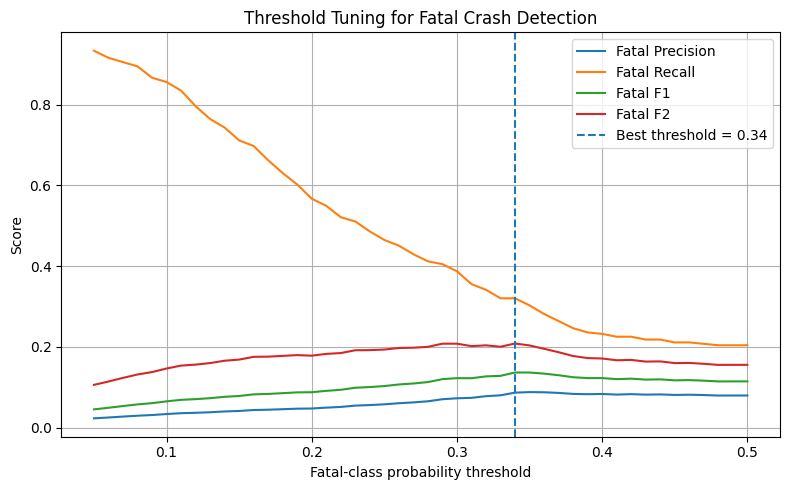

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Fatal Precision"], label="Fatal Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Fatal Recall"], label="Fatal Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Fatal F1"], label="Fatal F1")
plt.plot(threshold_df["Threshold"], threshold_df["Fatal F2"], label="Fatal F2")

plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.2f}")

plt.xlabel("Fatal-class probability threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Fatal Crash Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

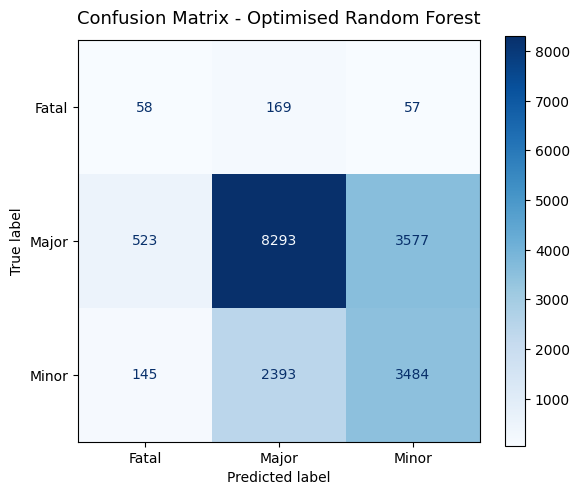

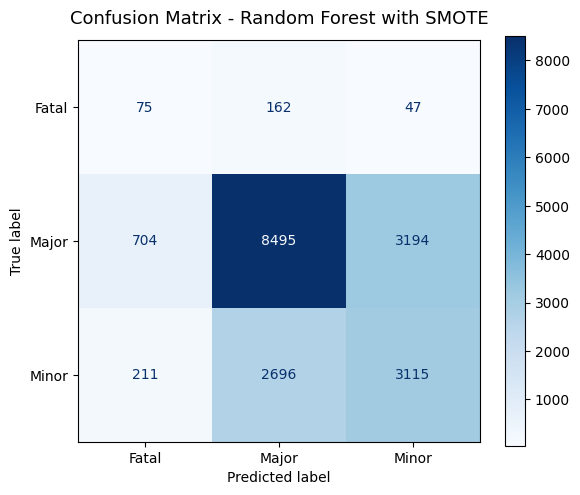

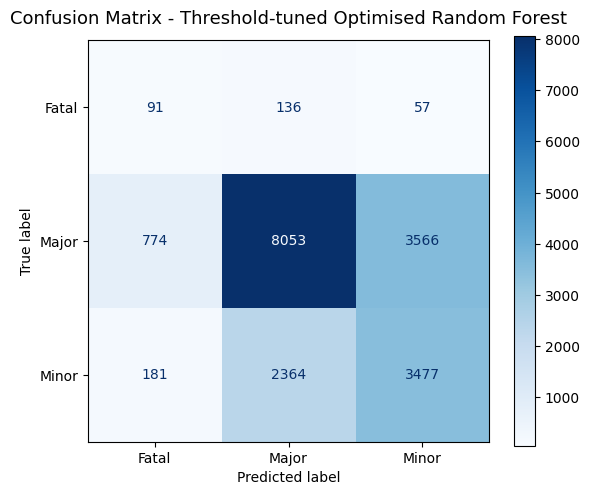

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make sure class names are in the correct order
class_names = ["Fatal", "Major", "Minor"]

def plot_and_save_confusion_matrix(y_true, y_pred, title, filename):
    """
    Plot and save a confusion matrix figure.
    """
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=True
    )

    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=0)
    plt.tight_layout()

    # Save figure for Overleaf
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# 1. Confusion matrix for Optimised Random Forest
plot_and_save_confusion_matrix(
    y_test,
    y_pred_rf_opt,
    "Confusion Matrix - Optimised Random Forest",
    "confusion_matrix_optimised_rf.png"
)


# 2. Confusion matrix for Random Forest + SMOTE
plot_and_save_confusion_matrix(
    y_test,
    y_pred_smote,
    "Confusion Matrix - Random Forest with SMOTE",
    "confusion_matrix_rf_smote.png"
)


# 3. Confusion matrix for Threshold-tuned Optimised Random Forest
plot_and_save_confusion_matrix(
    y_test,
    y_pred_threshold_final,
    "Confusion Matrix - Threshold-tuned Optimised Random Forest",
    "confusion_matrix_threshold_tuned_rf.png"
)

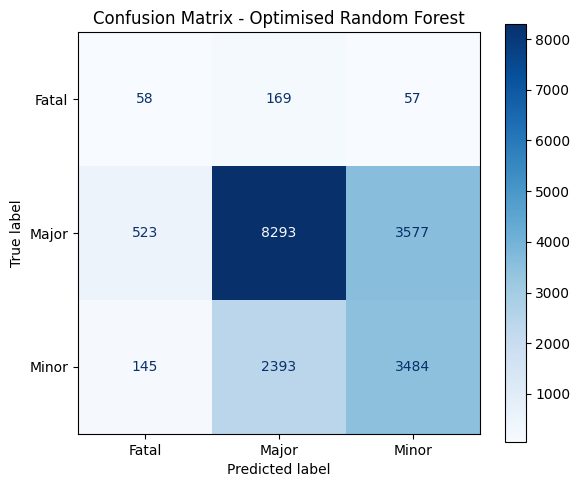

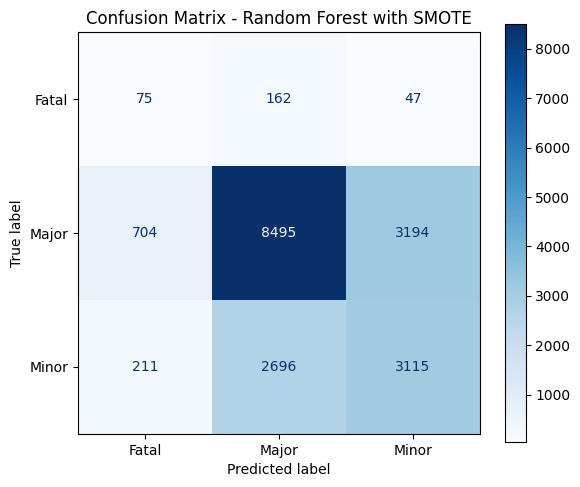

In [76]:
# ==========================================
# Confusion matrices for final report
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ["Fatal", "Major", "Minor"]

# Optimised Random Forest
cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_opt,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=True)

ax.set_title("Confusion Matrix - Optimised Random Forest")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig("confusion_matrix_optimised_rf.png", dpi=300, bbox_inches="tight")
plt.show()


# Random Forest + SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=True)

ax.set_title("Confusion Matrix - Random Forest with SMOTE")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig("confusion_matrix_rf_smote.png", dpi=300, bbox_inches="tight")
plt.show()

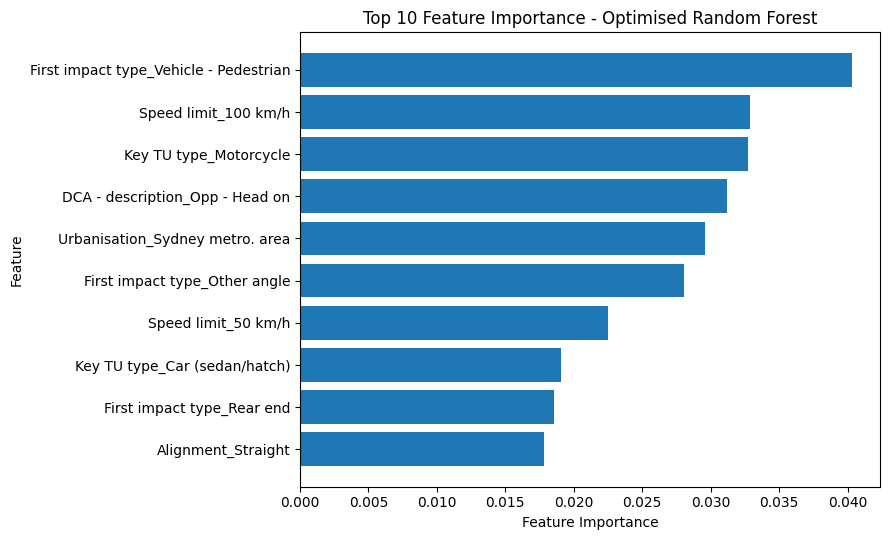

In [ ]:
import matplotlib.pyplot as plt

top10_plot = feature_importance_opt_df.head(10).copy()
top10_plot = top10_plot.sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5.5))

plt.barh(
    top10_plot["Feature"],
    top10_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Optimised Random Forest")

plt.tight_layout()

# Save for Overleaf
plt.savefig("top10_feature_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()